# Práctica B4-T2 · XAI — Concesión de crédito sensible al coste y auditoría

**Grupo:** Alonso · Raúl · Pietro
**Máster — Explainable AI (XAI)**

Construimos, **optimizamos bajo dos matrices de coste** y **auditamos** un modelo de
concesión de crédito sobre el dataset *Give Me Some Credit*. La variable objetivo es
`SeriousDlqin2yrs` = 1 si el cliente entró en **mora grave (≥90 días)** en 2 años.

Dos escenarios de coste (los dos tipos de error no cuestan lo mismo):

| Entregable | Coste FP | Coste FN | Lectura de negocio |
|---|---|---|---|
| `cs_produccion1.csv` | 1 | 1 | los dos errores pesan igual |
| `cs_produccion2.csv` | 1 | 10 | fallar un moroso cuesta 10× denegar a un buen cliente |

- **FP** (falso positivo): decimos *moroso* a un cliente bueno → le denegamos crédito sin motivo.
- **FN** (falso negativo): decimos *bueno* a un moroso → le concedemos crédito y no paga.

**Evaluación:** 50 % coste promedio en producción · 50 % calidad de la auditoría XAI.

### Índice
0. Configuración y reproducibilidad
1. Datos: limpieza y particiones
2. Modelos baseline
3. Framework sensible al coste (elección de umbral)
4. Predicciones de producción (los 2 CSV)
5. **Auditoría SHAP** (Alonso)
6. Modelo subrogado + otras técnicas (Raúl) — *pendiente*
7. Contrafactuals (Pietro) — *pendiente*
8. Reflexión final

> **Cómo está escrito esto:** cada bloque de código va seguido de una celda de texto que
> interpreta el resultado. El objetivo no es solo que funcione, sino **entender el porqué**.

## 0. Configuración y reproducibilidad

Cargamos la base común del grupo (los módulos `.py`). Todo el azar pasa por una única
semilla (`SEED=42`) definida en `config.py`, de modo que los tres miembros del grupo
obtenemos exactamente los mismos splits, modelos y resultados.

In [1]:
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
import data_prep
import baselines
import cost_sensitive

config.fijar_semillas()          # fija numpy / random / PYTHONHASHSEED
config.crear_directorios()
print("Semilla global:", config.SEED)
print("Matrices de coste:", {k: (v['c_fp'], v['c_fn']) for k, v in config.MATRICES_COSTE.items()})

Semilla global: 42
Matrices de coste: {'produccion1': (1, 1), 'produccion2': (1, 10)}


## 1. Datos: limpieza y particiones

Regeneramos los datos procesados desde `data/raw/`. La limpieza (documentada en
`data_prep.py`) resuelve los problemas reales del dataset:

- **Renta ausente (~20 %)**: no borramos filas (en producción hay que predecir todas);
  imputamos la mediana y añadimos un flag `MonthlyIncome_missing`, porque *que falte la
  renta* es en sí informativo.
- **Centinelas 96/98** en las columnas de retrasos: son códigos de "no disponible", no un
  número real de retrasos → los tratamos como nulos y los imputamos.
- **Outliers** de ratios (utilización de 20.000, rentas de 3 M) → recorte (winsorizado) al
  percentil 99,5 de train.
- **Edades imposibles** (0) → a rango [18, 100].

Punto clave de rigor: los parámetros de limpieza se aprenden **solo en train** y se aplican
igual a validación, test y producción (sin fuga de información).

In [2]:
data_prep.main()   # genera data/processed/{train,val,test,produccion}.csv

Datos procesados y guardados en data/processed/:
  train        filas= 67200  % mora= 6.68  nulos=0
  val          filas= 16800  % mora= 6.68  nulos=0
  test         filas= 21000  % mora= 6.69  nulos=0
  produccion   filas= 45000  (sin target)      nulos=0

Columnas finales (11): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'MonthlyIncome_missing']


Cargamos los splits ya limpios y comprobamos el desbalanceo de clases.

In [3]:
splits = data_prep.cargar_splits()
X_train, y_train = splits["X_train"], splits["y_train"]
X_val,   y_val   = splits["X_val"],   splits["y_val"]
X_test,  y_test  = splits["X_test"],  splits["y_test"]

resumen = pd.DataFrame({
    "n_filas": [len(y_train), len(y_val), len(y_test), len(splits["X_prod"])],
    "%_mora":  [100*y_train.mean(), 100*y_val.mean(), 100*y_test.mean(), np.nan],
}, index=["train", "val", "test", "produccion"]).round(2)
resumen

,n_filas,%_mora
train,67200,6.68
val,16800,6.68
test,21000,6.69
produccion,45000,NaN


**Interpretación.** El split es estratificado: las tres particiones mantienen ~**6,7 %**
de morosos, igual que el dataset original. Es un problema **fuertemente desbalanceado**:
un modelo que dijera "todos buenos" acertaría el 93 % de las veces pero sería inútil para
el negocio. Por eso más abajo **no** miraremos accuracy, sino **coste**. Producción tiene
45.000 clientes sin etiqueta: son los que debemos predecir.

## 2. Modelos baseline

Entrenamos cinco modelos, ordenados de más interpretable a más "caja negra":
logística, árbol, random forest, gradient boosting y LightGBM. Los guardamos en `models/`.

**Decisión importante:** *no* usamos `class_weight`/balanceo. El desbalanceo lo trataremos
en la sección 3 eligiendo el **umbral** de decisión según el coste. Así entrenamos para
estimar bien la probabilidad de mora y el mismo modelo sirve para las dos matrices de coste
(solo cambia el umbral). La métrica aquí es **AUC**, que no depende del umbral.

In [4]:
resumen_baselines = baselines.entrenar_y_guardar()
tabla_auc = (pd.DataFrame(resumen_baselines).T[["auc_val"]]
             .sort_values("auc_val", ascending=False).round(4))
tabla_auc

  logreg   AUC_val=0.8468  (0.1s)  -> models/logreg.joblib
  tree     AUC_val=0.8343  (0.1s)  -> models/tree.joblib


  rf       AUC_val=0.8624  (1.9s)  -> models/rf.joblib


  gb       AUC_val=0.8622  (7.6s)  -> models/gb.joblib


  lgbm     AUC_val=0.8598  (0.4s)  -> models/lgbm.joblib


,auc_val
rf,0.8624
gb,0.8622
lgbm,0.8598
logreg,0.8468
tree,0.8343


**Interpretación.** Los modelos de árboles (random forest, gradient boosting, LightGBM)
alcanzan un AUC de ~**0,86**, algo por encima de la logística (~0,85). Son cifras razonables
para este dataset: hay señal, pero el problema tiene ruido intrínseco (personas con buen
perfil que impagan y viceversa). El AUC alto de la logística indica además que buena parte
de la señal es casi lineal, algo que confirmaremos con SHAP.

## 3. Framework sensible al coste (la parte que decide la nota de "resultados")

**La idea central.** El modelo da una probabilidad de mora *p*. Como el coste de los dos
errores es distinto, **no** debemos predecir la clase más probable (umbral 0,5), sino
elegir el umbral *t* que **minimiza el coste esperado**. Teóricamente el umbral óptimo es

$$t^\* = \frac{c_{FP}}{c_{FP}+c_{FN}}$$

- Matriz A (1,1): $t^\*=0{,}5$.
- Matriz B (1,10): $t^\*=1/11\approx 0{,}091$ → bajamos mucho el listón para "cazar" morosos,
  porque dejar pasar uno cuesta 10 veces más que denegar a un buen cliente.

En la práctica **buscamos el umbral empíricamente sobre validación** (más robusto que la
fórmula) y luego lo aplicamos a test para estimar el coste de forma honesta.

In [5]:
tablas, seleccion = cost_sensitive.ejecutar_todo()

for nombre, tabla in tablas.items():
    cfg = config.MATRICES_COSTE[nombre]
    print(f"=== Matriz {nombre}  (FP={cfg['c_fp']}, FN={cfg['c_fn']}) ===")
    display(tabla)
    sel = seleccion[nombre]
    print(f"MEJOR modelo: {sel['modelo']}  | umbral={sel['umbral']:.4f}  | coste_test={sel['coste_test']:.5f}")
    print(f"Referencia trivial (test): {  {k: round(v,4) for k,v in sel['trivial'].items()} }")
    print()

=== Matriz produccion1  (FP=1, FN=1) ===


,matriz,modelo,umbral_opt,coste_val,coste_test
0,produccion1,logreg,0.3945,0.06179,0.06357
1,produccion1,gb,0.5658,0.06226,0.06371
2,produccion1,rf,0.4387,0.06137,0.06414
3,produccion1,lgbm,0.5425,0.06202,0.06424
4,produccion1,tree,0.5789,0.06393,0.06429


MEJOR modelo: logreg  | umbral=0.3945  | coste_test=0.06357
Referencia trivial (test): {'conceder_a_todos': 0.0669, 'denegar_a_todos': 0.9331}

=== Matriz produccion2  (FP=1, FN=10) ===


,matriz,modelo,umbral_opt,coste_val,coste_test
0,produccion2,lgbm,0.0999,0.32149,0.32538
1,produccion2,rf,0.0986,0.32464,0.33176
2,produccion2,gb,0.0931,0.32417,0.33324
3,produccion2,tree,0.1105,0.34048,0.34238
4,produccion2,logreg,0.0763,0.35220,0.35657


MEJOR modelo: lgbm  | umbral=0.0999  | coste_test=0.32538
Referencia trivial (test): {'conceder_a_todos': 0.6686, 'denegar_a_todos': 0.9331}



**Interpretación.**

- **Matriz A (1,1).** Todos los modelos quedan en un coste ~**0,063**, apenas por debajo de
  la estrategia trivial "conceder a todos" (~0,067). Tiene sentido: con costes iguales y solo
  un 6,7 % de morosos, equivocarse poco ya es barato y el margen de mejora es pequeño. Las
  diferencias entre modelos son casi ruido; el umbral óptimo queda cerca de 0,4–0,5.

- **Matriz B (1,10).** Aquí el modelo **sí marca la diferencia**: el mejor coste (~**0,33**)
  es la mitad que "conceder a todos" (~0,67). El umbral óptimo baja a ~**0,10**, muy cerca del
  teórico 1/11: el modelo deniega a muchos más clientes con tal de no dejar pasar morosos caros.
  LightGBM/Random Forest son los mejores en este escenario, que es el exigente.

En ambos casos batimos claramente a "denegar a todos" (coste 0,93), que arruinaría el negocio.

## 4. Predicciones de producción (los 2 CSV a entregar)

`cost_sensitive.ejecutar_todo()` ya ha escrito `cs_produccion1.csv` y `cs_produccion2.csv`
con el mejor modelo de cada matriz y su umbral. Cada CSV tiene una columna
`SeriousDlqin2yrs` con la predicción 0/1, una fila por cliente y en el mismo orden que
`cs_produccion.csv`. Comprobamos el resultado.

In [6]:
for f in [config.CS_PRODUCCION_1, config.CS_PRODUCCION_2]:
    d = pd.read_csv(f)
    print(f"{f.name}: {len(d)} filas | deniegan (pred=1): {int(d.iloc[:,0].sum())} "
          f"({100*d.iloc[:,0].mean():.1f}%)")

cs_produccion1.csv: 45000 filas | deniegan (pred=1): 1225 (2.7%)
cs_produccion2.csv: 45000 filas | deniegan (pred=1): 7534 (16.7%)


**Interpretación.** Con la matriz A denegamos solo ~**2,7 %** de las solicitudes (somos
permisivos: como fallar un moroso cuesta lo mismo que rechazar a uno bueno, no compensa
denegar mucho). Con la matriz B denegamos ~**16,7 %**: al penalizar 10× el moroso, el modelo
se vuelve mucho más cauto. Es exactamente el comportamiento económico que esperábamos y
muestra que el umbral está haciendo su trabajo.

## 5. Auditoría SHAP — *Alonso*

Auditamos el modelo **LightGBM** (fuerte y, además, el ganador en la matriz B) con **SHAP**.
SHAP reparte cada predicción entre las variables usando los valores de Shapley (teoría de
juegos): dice cuánto y en qué dirección empuja cada variable. El valor SHAP está en escala
de **log-odds**: positivo = empuja hacia *mora (1)*; negativo = empuja hacia *buen cliente (0)*.

Distinguimos dos niveles: **global** (el modelo en su conjunto) y **local** (un cliente
concreto).

In [7]:
import shap
import shap_audit

explanation, X_muestra, modelo_lgbm = shap_audit.calcular_shap()
print("SHAP calculado sobre", X_muestra.shape[0], "clientes de test.")

SHAP calculado sobre 2000 clientes de test.


### 5.1 Global — beeswarm (importancia y signo)

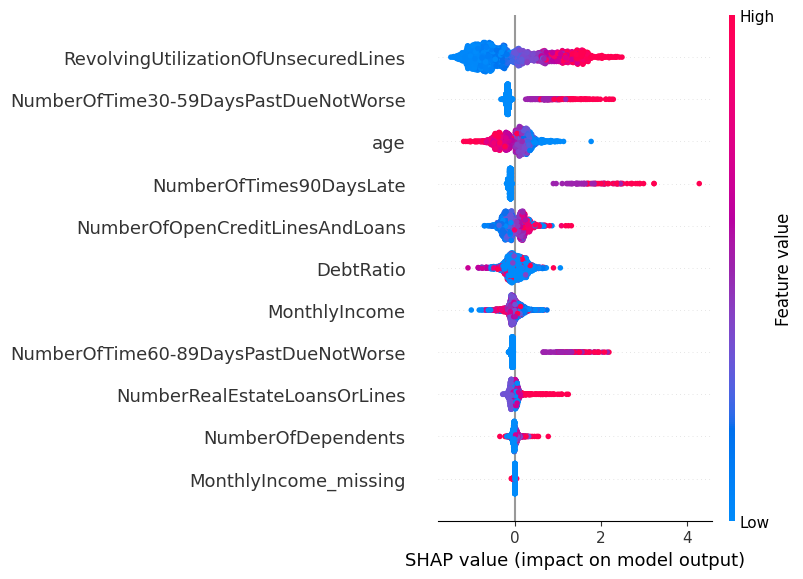

In [8]:
shap.plots.beeswarm(explanation, max_display=12, show=False)
plt.tight_layout(); plt.show()

**Interpretación.** Cada punto es un cliente; el color es el valor de la variable
(rojo alto, azul bajo). Se lee importancia (orden vertical) y dirección a la vez:

- **RevolvingUtilizationOfUnsecuredLines** (uso del crédito disponible) es la variable más
  influyente: valores altos (rojo) tienen SHAP positivo → **más riesgo de mora**. Es el
  hallazgo más intuitivo: quien tiene las tarjetas al límite es más arriesgado.
- Los **retrasos** (30-59, 90 días, 60-89) empujan con fuerza hacia mora cuando son altos.
- **age** funciona al revés: rojo (mayor edad) tiene SHAP negativo → **menos riesgo**.
- **MonthlyIncome_missing** casi no aporta: que falte la renta no discrimina mucho por sí solo.

El modelo usa variables **razonables y de negocio**, no espurias: buena señal de auditoría.

### 5.2 Global — importancia media (barras)

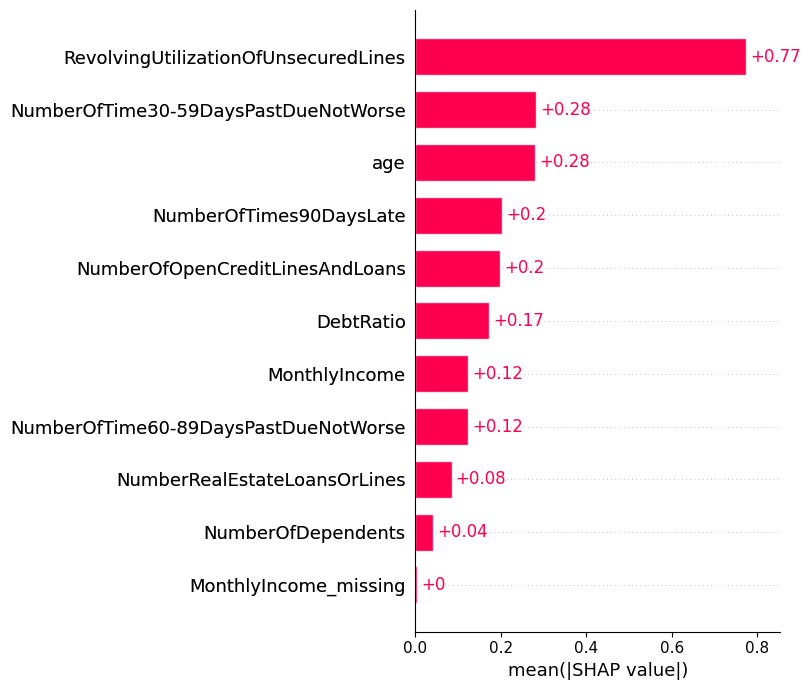

In [9]:
shap.plots.bar(explanation, max_display=12, show=False)
plt.tight_layout(); plt.show()

**Interpretación.** Es el ranking limpio por magnitud media |SHAP|. Confirma que el
riesgo se explica sobre todo por **utilización del crédito + historial de retrasos + edad**.
Las variables de estructura financiera (nº de líneas, inmuebles, dependientes) tienen un peso
secundario.

### 5.3 Global — dependence de la variable top

Cómo cambia el efecto de una variable según su valor (relación no lineal + interacciones).

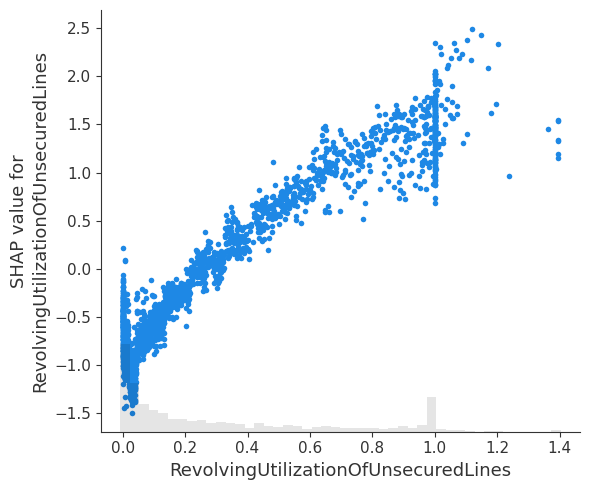

In [10]:
feat = "RevolvingUtilizationOfUnsecuredLines"
shap.plots.scatter(explanation[:, feat], show=False)
plt.tight_layout(); plt.show()

**Interpretación.** El efecto de la utilización es **fuertemente creciente**: cerca de 0
el SHAP es negativo (protege), y a partir de ~0,5–1,0 se dispara hacia riesgo positivo. No es
lineal: pasar de 0,1 a 0,3 apenas mueve, pero pasar de 0,6 a 1,0 dispara el riesgo. Esto
justifica usar un modelo no lineal (LightGBM) frente a la pura logística.

### 5.4 Local — waterfall de casos concretos

Explicamos tres clientes de test: el de **mayor** riesgo, el de **menor** riesgo y uno en la
**frontera** (P≈0,5). El waterfall descompone su predicción como base + suma de contribuciones.


----- ALTO_RIESGO  |  P(mora) = 0.964 -----


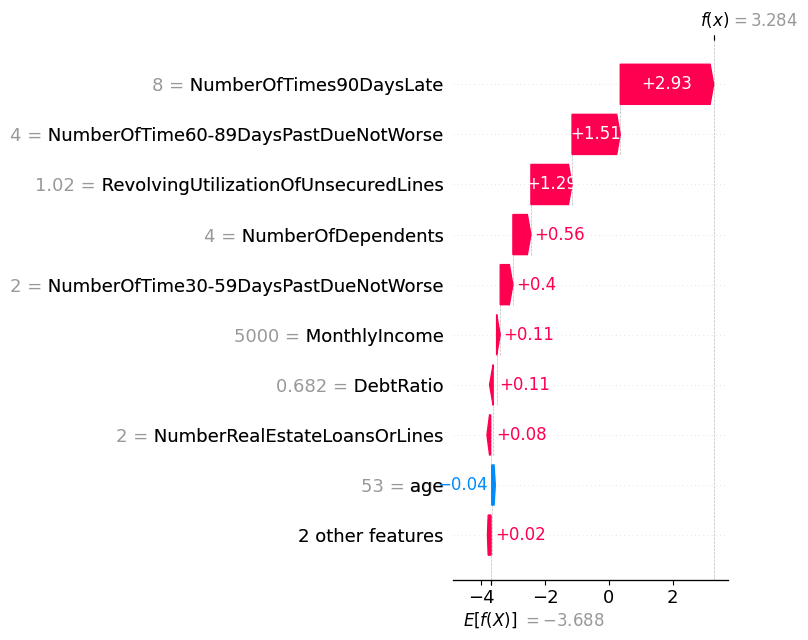


----- BAJO_RIESGO  |  P(mora) = 0.000 -----


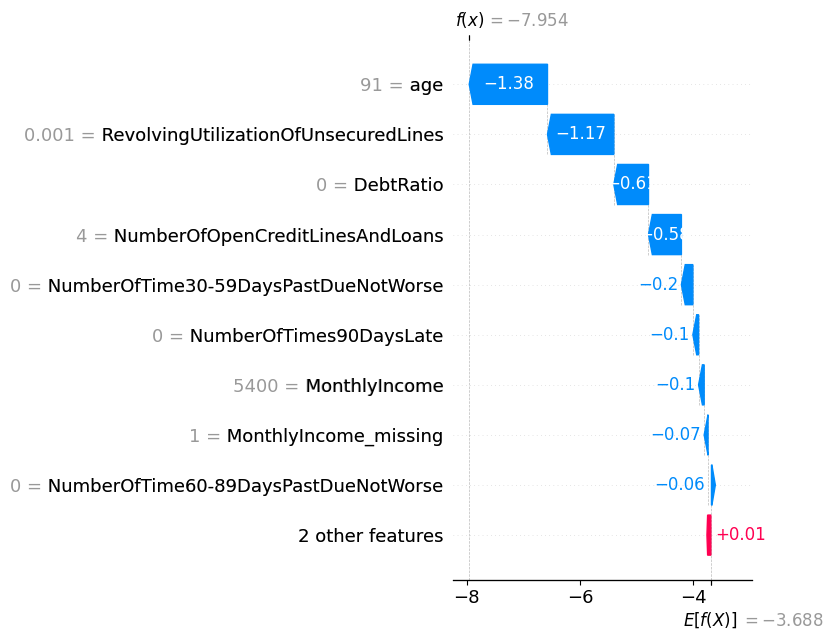


----- FRONTERA  |  P(mora) = 0.500 -----


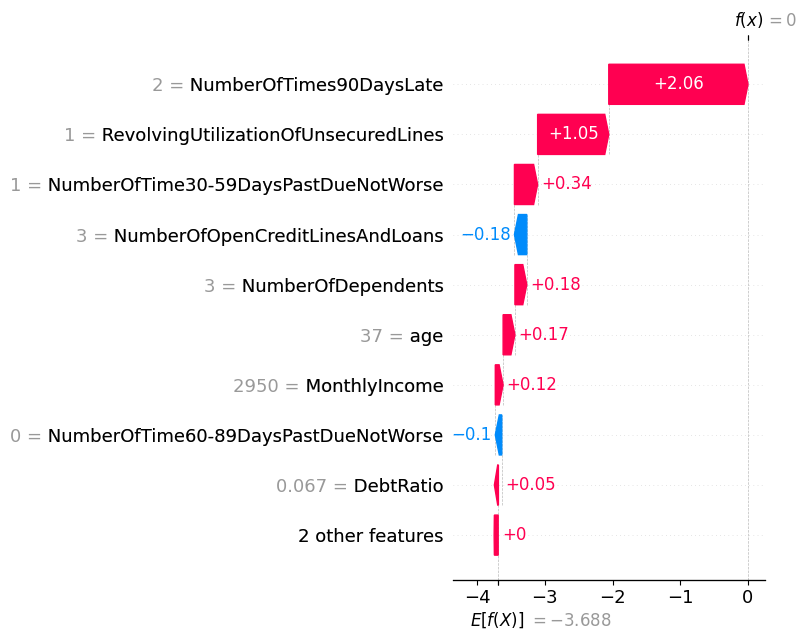

In [11]:
casos, X_test_full, prob_full = shap_audit.seleccionar_casos_locales(modelo_lgbm)
explainer = shap.TreeExplainer(modelo_lgbm)
for etiqueta, idx in casos.items():
    exp = explainer(X_test_full.iloc[[idx]])
    if exp.values.ndim == 3:
        exp = exp[:, :, 1]
    print(f"\n----- {etiqueta.upper()}  |  P(mora) = {prob_full[idx]:.3f} -----")
    shap.plots.waterfall(exp[0], max_display=10, show=False)
    plt.tight_layout(); plt.show()

**Interpretación.**

- **Alto riesgo (P≈0,96).** La predicción se dispara por un historial de impagos demoledor:
  varios retrasos de 90 días (+2,9 en log-odds), retrasos de 60-89 días y utilización > 1.
  El modelo lo deniega con enorme confianza y *sabemos exactamente por qué*.
- **Bajo riesgo (P≈0,00).** Utilización casi nula, sin retrasos y edad alta: todo empuja hacia
  "buen cliente". Concesión clara.
- **Frontera (P≈0,5).** Señales mezcladas: algún factor de riesgo compensado por otros
  protectores. Son los casos donde el **umbral** decide y donde más importa la explicación.

Esta capacidad de justificar **caso a caso** es justo lo que necesitaríamos para responder a
un cliente que pregunta por qué se le deniega el crédito (lo desarrolla Pietro en la sección 7).

## 6. Modelo subrogado + otras técnicas — *Raúl* (pendiente)

Flujo independiente (ver `REPARTO_TAREAS.md` y el futuro `surrogate_audit.py`):

- **Árbol subrogado:** entrenar un `DecisionTreeClassifier` poco profundo para que imite la
  salida de LightGBM (etiqueta = `lgbm.predict(X)`, *no* el target real) y extraer **reglas
  legibles**. Reportar la **fidelidad** (accuracy del subrogado reproduciendo la caja negra).
- **Permutation importance** y **PDP/ICE** como técnicas complementarias.

Debe cargar los mismos splits (`data_prep.cargar_splits()`) y el mismo modelo
(`baselines.load_baseline("lgbm")`). Esqueleto mínimo para arrancar:

In [12]:
# --- ESQUELETO (Raúl) — descomentar y desarrollar en surrogate_audit.py ---
# from sklearn.tree import DecisionTreeClassifier, export_text
# lgbm = baselines.load_baseline("lgbm")
# y_caja_negra = lgbm.predict(X_train)                 # imitamos la CAJA NEGRA
# surrogate = DecisionTreeClassifier(max_depth=3, random_state=config.SEED).fit(X_train, y_caja_negra)
# fidelidad = (surrogate.predict(X_test) == lgbm.predict(X_test)).mean()
# print("Fidelidad del subrogado:", round(fidelidad, 3))
# print(export_text(surrogate, feature_names=list(X_train.columns)))
print("Sección de Raúl: pendiente de desarrollar.")

Sección de Raúl: pendiente de desarrollar.


## 7. Contrafactuals — *Pietro* (pendiente)

Flujo independiente (ver `REPARTO_TAREAS.md` y el futuro `counterfactual_audit.py`):

- Para clientes reales de clase 0 y clase 1, encontrar el **cambio mínimo** en variables
  **accionables** (utilización, nº de retrasos… la edad *no* se puede cambiar) que voltearía
  la decisión: *"si redujeras la utilización a 0,3 y no tuvieras el retraso de 90 días, se te
  aprobaría"*.
- Redactar la **explicación al cliente** al que se le deniega el crédito (conecta con la
  sección 5.4: los waterfalls ya dan el "porqué"; el contrafactual da el "qué cambiar").

Puede usarse `dice-ml` o una búsqueda propia perturbando variables hasta cruzar el umbral de
`cost_sensitive`. Esqueleto mínimo:

In [13]:
# --- ESQUELETO (Pietro) — descomentar y desarrollar en counterfactual_audit.py ---
# lgbm   = baselines.load_baseline("lgbm")
# umbral = seleccion["produccion2"]["umbral"]           # umbral de la matriz B
# idx    = casos["frontera"]                             # un cliente denegado
# base   = X_test_full.iloc[[idx]].copy()
# # Ejemplo naive: bajar la utilización hasta cruzar el umbral
# for val in [1.0, 0.7, 0.5, 0.3, 0.1]:
#     tmp = base.copy(); tmp["RevolvingUtilizationOfUnsecuredLines"] = val
#     print(val, "-> P(mora)=", round(lgbm.predict_proba(tmp)[0,1], 3),
#           "DENIEGA" if lgbm.predict_proba(tmp)[0,1] >= umbral else "APRUEBA")
print("Sección de Pietro: pendiente de desarrollar.")

Sección de Pietro: pendiente de desarrollar.


## 8. Reflexión final

**Sobre los resultados (coste).** El aprendizaje central de la práctica es que en un problema
desbalanceado y con costes asimétricos, *el modelo importa menos que la decisión*. Con la
matriz A (costes iguales) casi cualquier modelo empata con "conceder a todos", porque los
morosos son raros y baratos de asumir. Es en la matriz B (FN=10) donde optimizar el **umbral**
de decisión divide el coste a la mitad frente a la estrategia trivial. La misma probabilidad
del modelo, leída con dos umbrales distintos (0,5 vs ~0,10), produce dos políticas de negocio
opuestas: permisiva (deniega 2,7 %) vs cauta (deniega 16,7 %).

**Sobre la auditoría (SHAP).** El modelo se apoya en variables **económicamente sensatas** y
no en artefactos: utilización del crédito, historial de retrasos y edad. La relación es no
lineal (dependence de la utilización), lo que justifica un modelo de árboles frente a la
logística. A nivel local, los waterfalls permiten justificar cada decisión —requisito
imprescindible para un modelo de crédito, tanto por transparencia con el cliente como por
cumplimiento regulatorio.

**Coherencia coste ↔ explicación.** Lo que el modelo *usa* (SHAP) y lo que el modelo *decide*
(umbral de coste) son coherentes: en la matriz B el sistema deniega a clientes con utilización
alta y retrasos, que es precisamente lo que SHAP identifica como conductor del riesgo. No hay
señal de que el modelo esté "haciendo trampa" con variables espurias.

**Limitaciones y siguientes pasos.** (1) No hemos calibrado las probabilidades ni hecho
búsqueda de hiperparámetros: el foco es la auditoría, no exprimir el AUC. (2) Faltan por
consolidar los flujos de Raúl (subrogado + PDP/ICE) y Pietro (contrafactuals), que cerrarán
el "qué cambiar" para un cliente denegado. (3) Convendría revisar equidad (fairness) por
grupos de edad antes de un despliegue real.